In [1]:
from IPython.display import Image, display
import PIL
import matplotlib.pyplot as plt
from pathlib import Path
import folium
from folium.plugins import MarkerCluster
import numpy as np
import yaml
import os

import cv2
import torch
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader, random_split

from utility import latlon_to_yaw, euler_from_quaternion, transform_2d_points, resizecrop_matrix, crop_matrix, cls2one_hot, colorize_depth, quaternion_to_yaw
from config import GlobalConfig

config = GlobalConfig()
root_dir = Path(config.root_dir)

dir_meta = root_dir / "meta"
dir_rgb_front = root_dir / "camera" / "rgb"
dir_rgb_seg = root_dir / "camera" / "seg" / "img"
dir_rgb_seg_map = root_dir / "camera" / "seg" / "map"
dir_depth_front = root_dir / "camera" / "depth" / "map"
dir_depth_front_img = root_dir / "camera" / "depth" / "img"
dir_depth_front_pcd = root_dir / "camera" / "depth" / "cld2"
dir_histo = root_dir / "camera" / "histogram"
dir_optflow = root_dir / "camera" / "optical_flow"

files = os.listdir(dir_meta)
files.sort()
files = [os.path.splitext(filename)[0] for filename in files] # remove extension string
len_files = len(files)

## RGB Images

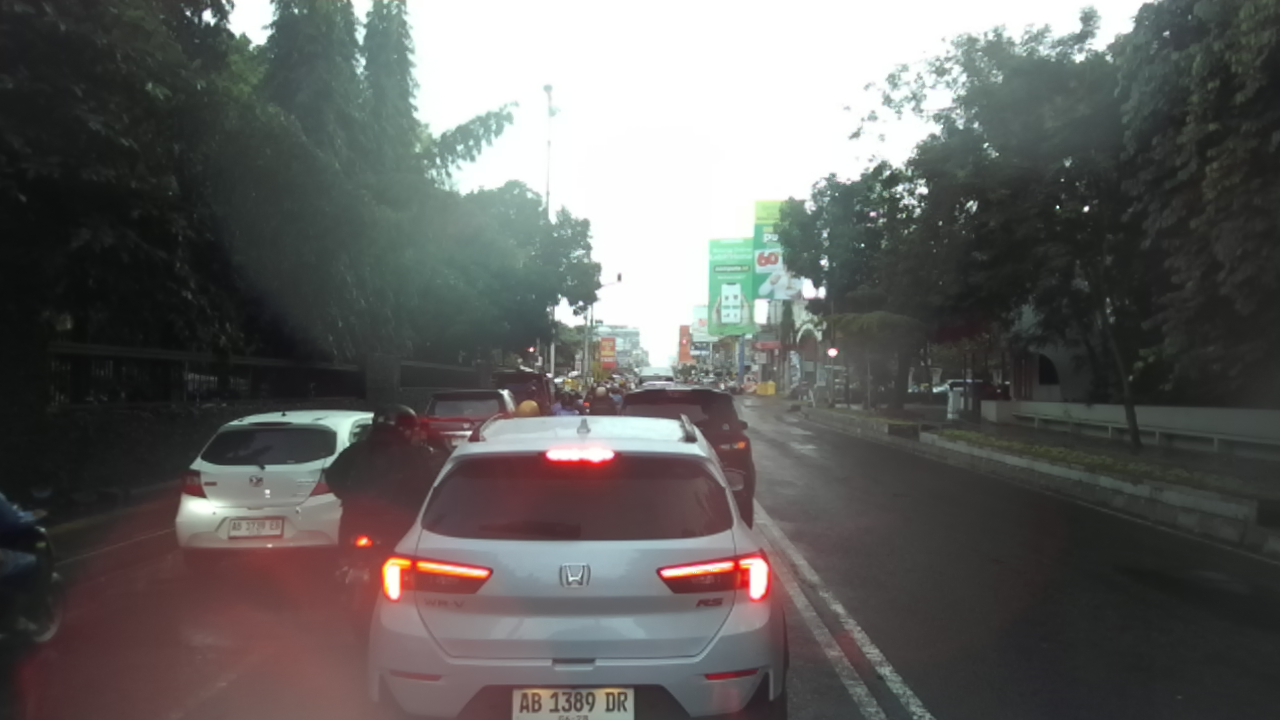

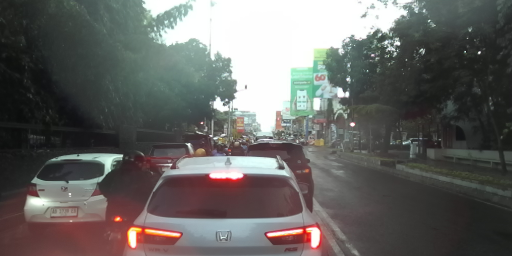

In [2]:
img = f'{dir_rgb_front}/{files[5]}.png'
display(Image(filename=img))
rgb_img = cv2.imread(img)
rgb_cropped = crop_matrix(rgb_img, resize=config.scale, crop=[512, 1024])
cv2.imwrite(f"/media/mf/AUTODRIVING-4TB/ai23/temp/rgb_cropped.png", rgb_cropped)
display(Image(filename="/media/mf/AUTODRIVING-4TB/ai23/temp/rgb_cropped.png"))

## Visulize the Segmentation Camera

(720, 1280, 3)
(20, 720, 1280)
Class 0: 165981 pixels
Class 1: 2749 pixels
Class 2: 22962 pixels
Class 3: 28862 pixels
Class 4: 26510 pixels
Class 5: 2466 pixels
Class 6: 329 pixels
Class 7: 594 pixels
Class 8: 353520 pixels
Class 9: 15857 pixels
Class 10: 113486 pixels
Class 11: 1210 pixels
Class 12: 65 pixels
Class 13: 187009 pixels
Class 14: 0 pixels
Class 15: 0 pixels
Class 16: 0 pixels
Class 17: 0 pixels
Class 18: 0 pixels
Class 19: 0 pixels
idx class:  0
nama class:  None


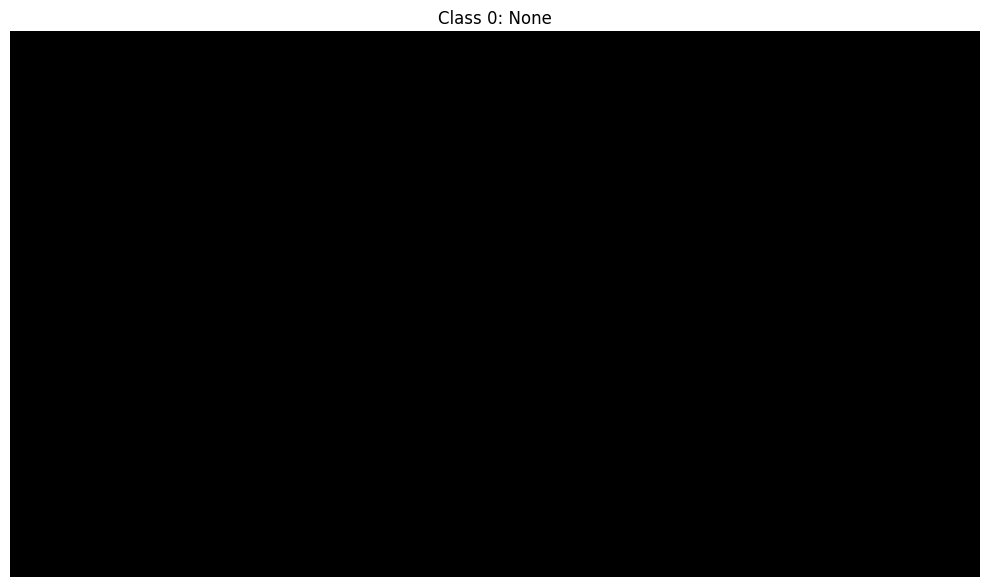

idx class:  1
nama class:  road


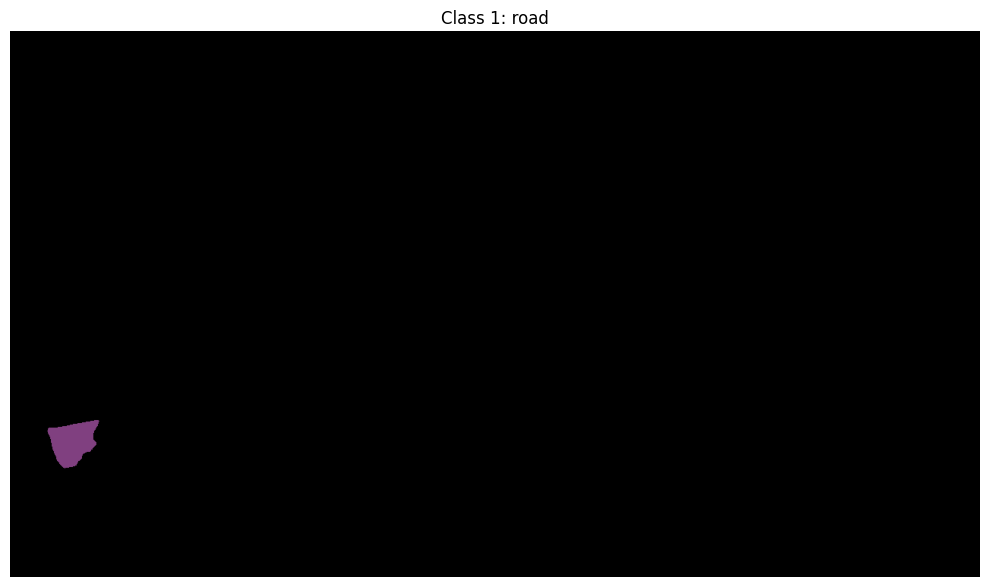

idx class:  2
nama class:  sidewalk


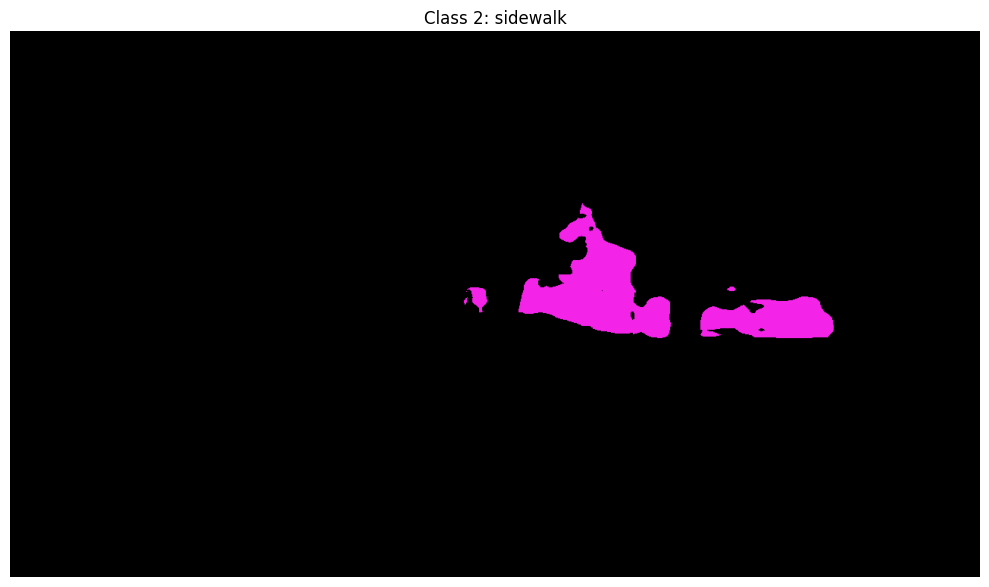

idx class:  3
nama class:  building


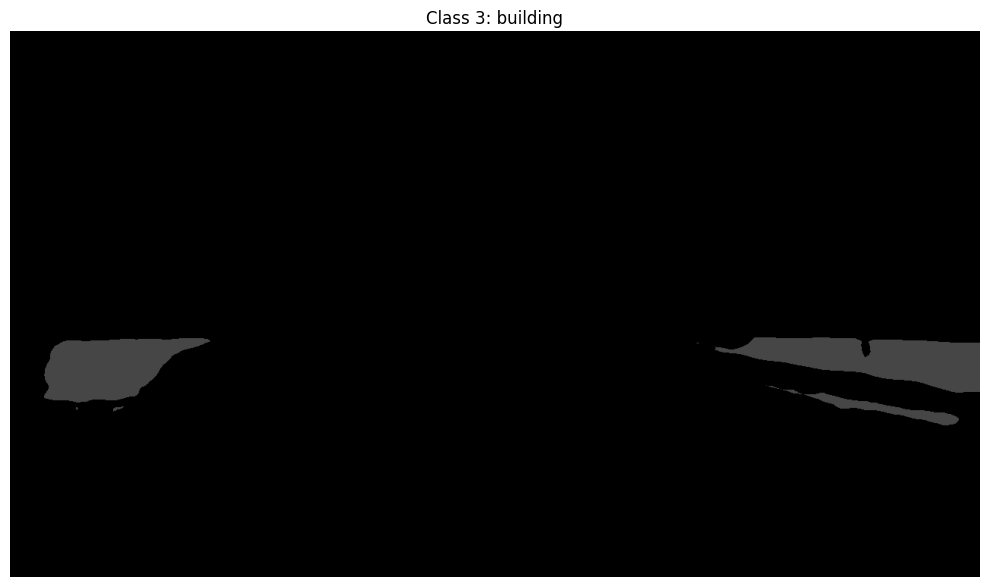

idx class:  4
nama class:  wall


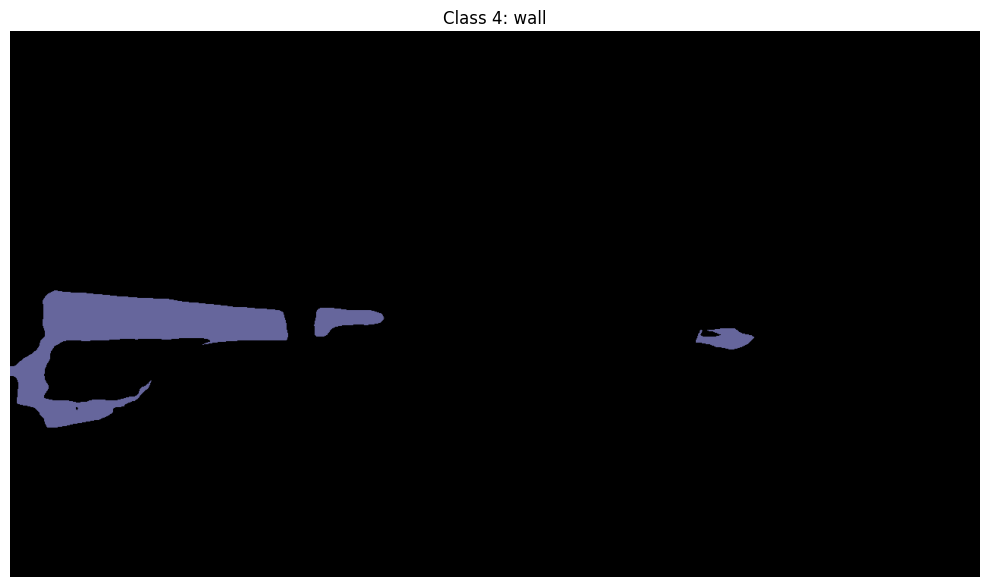

idx class:  5
nama class:  fence


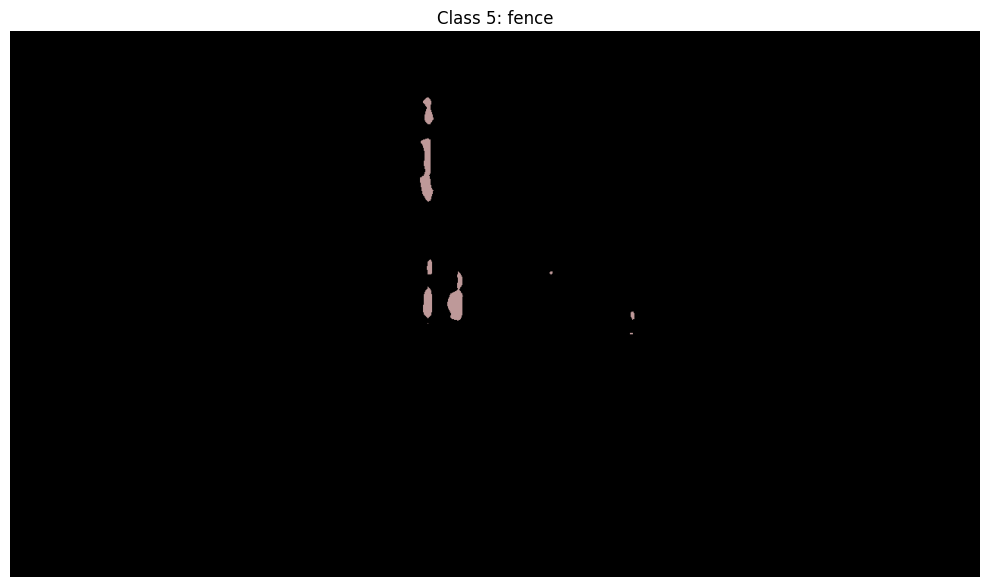

idx class:  6
nama class:  pole


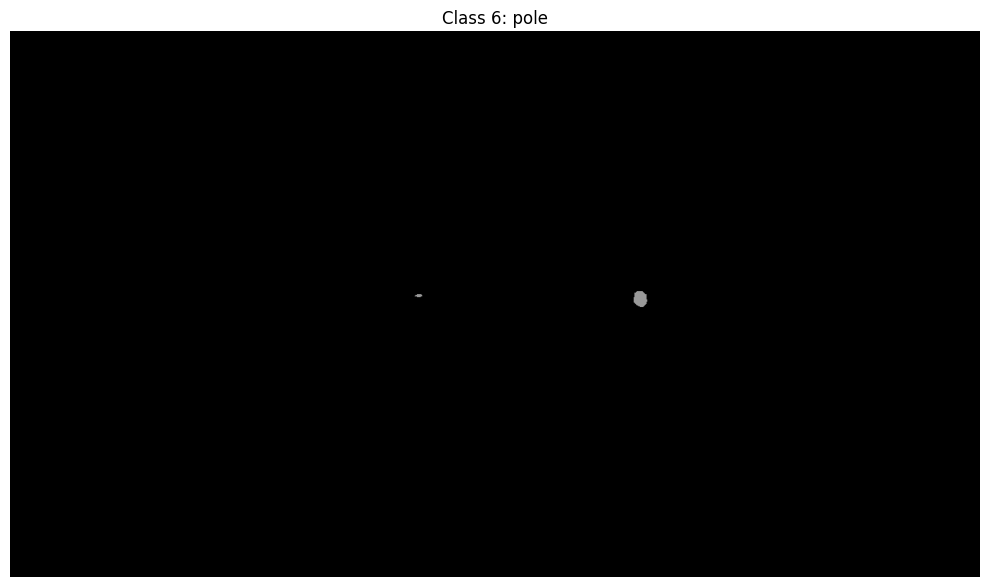

idx class:  7
nama class:  traffic light


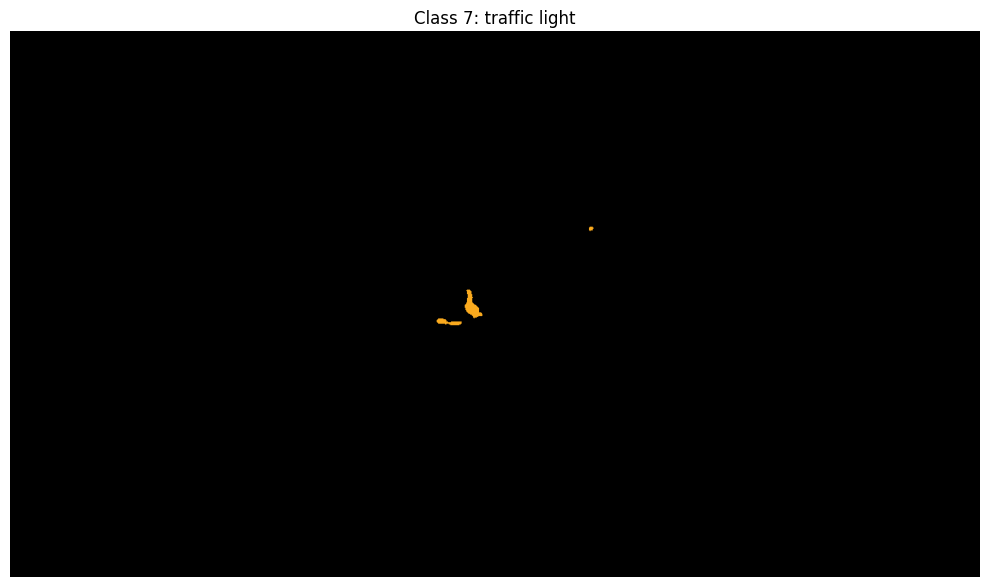

idx class:  8
nama class:  traffic sign


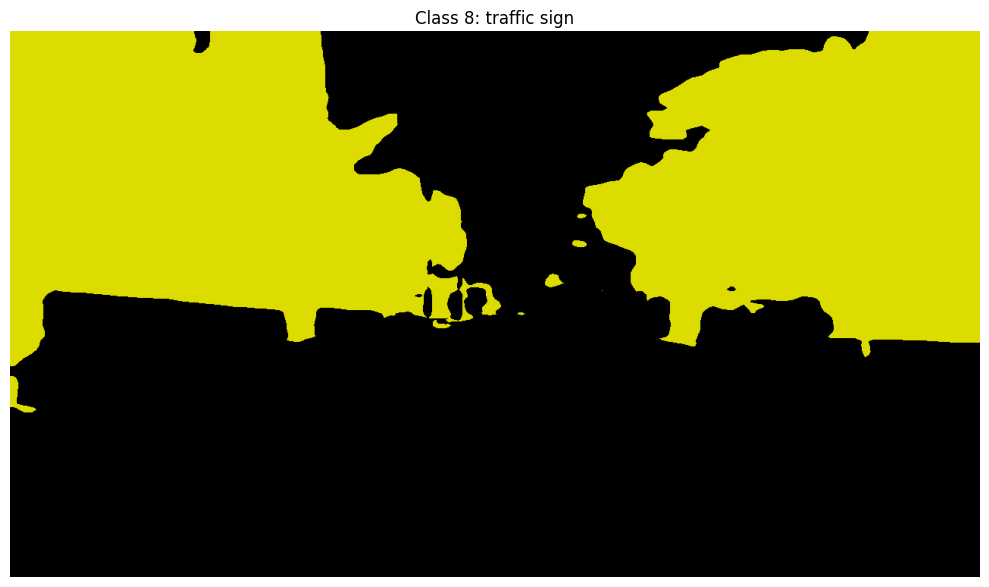

idx class:  9
nama class:  vegetation


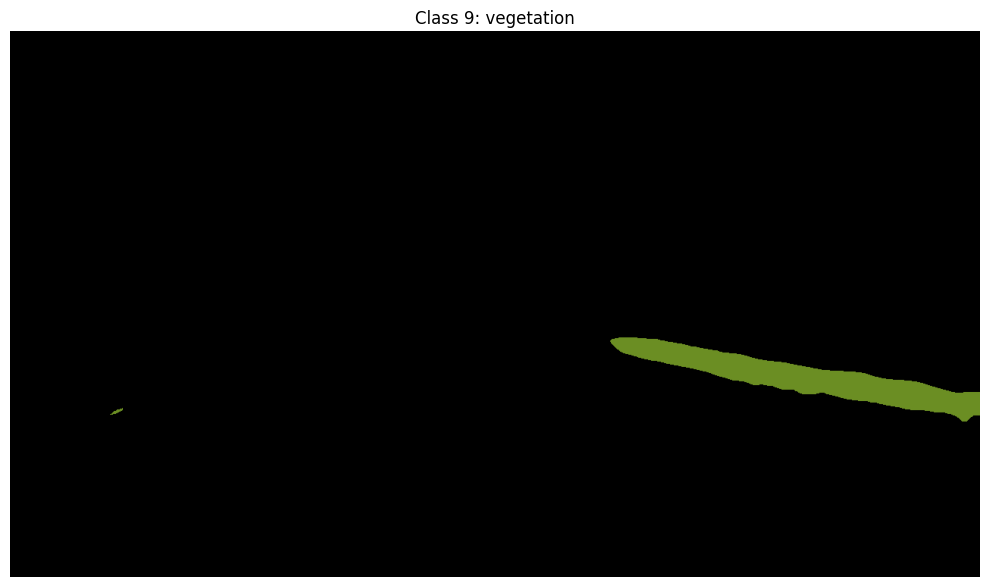

idx class:  10
nama class:  terrain


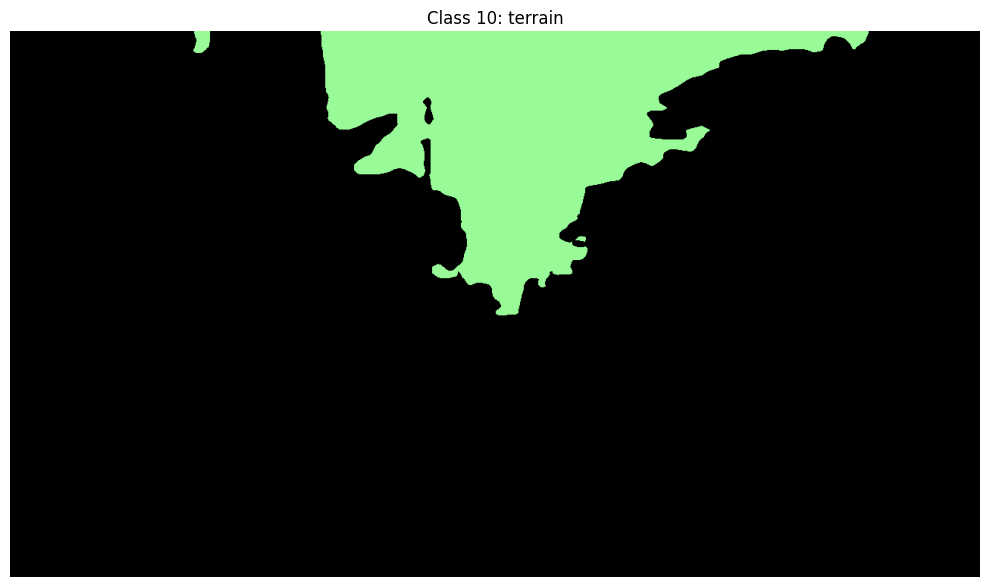

idx class:  11
nama class:  sky


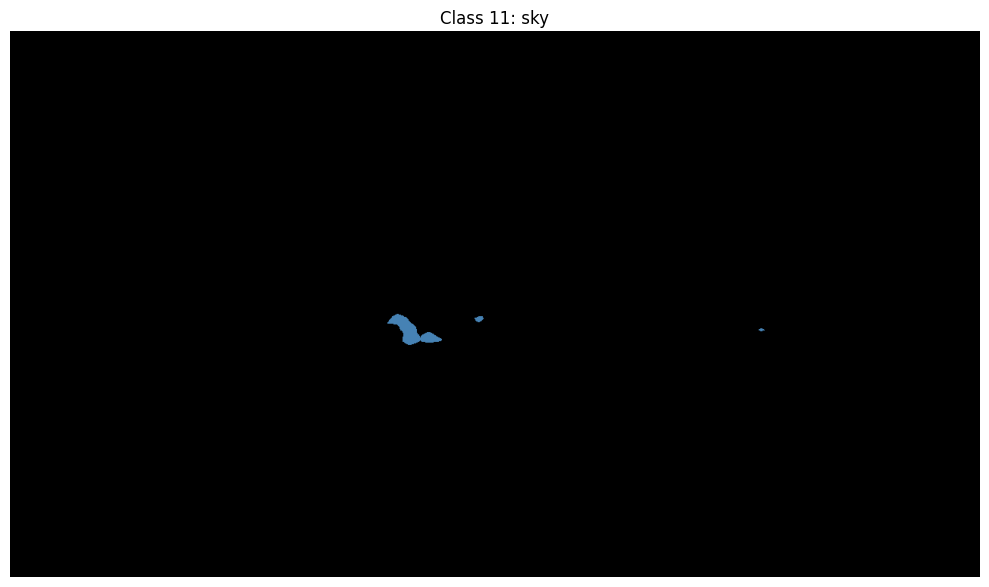

idx class:  12
nama class:  person


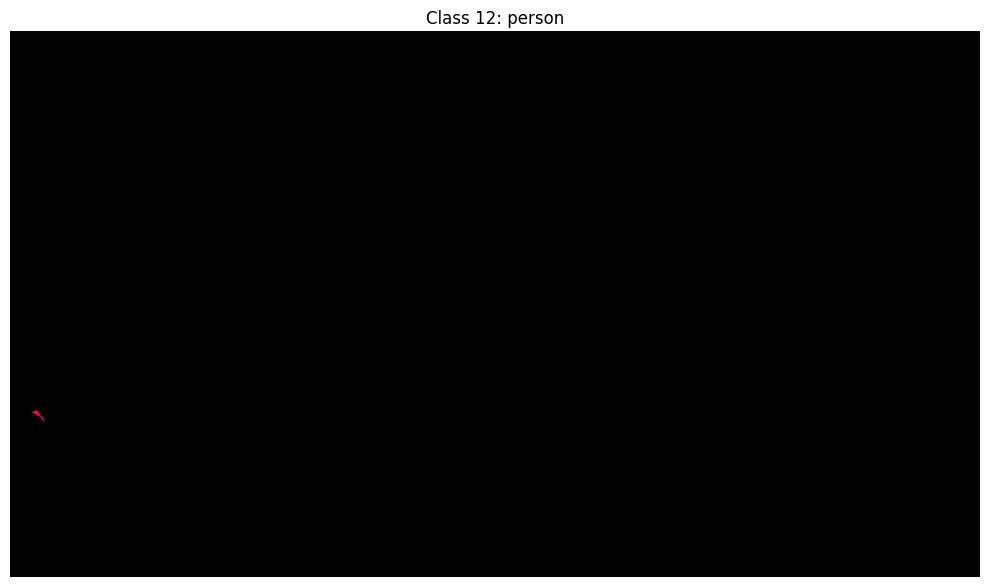

idx class:  13
nama class:  rider


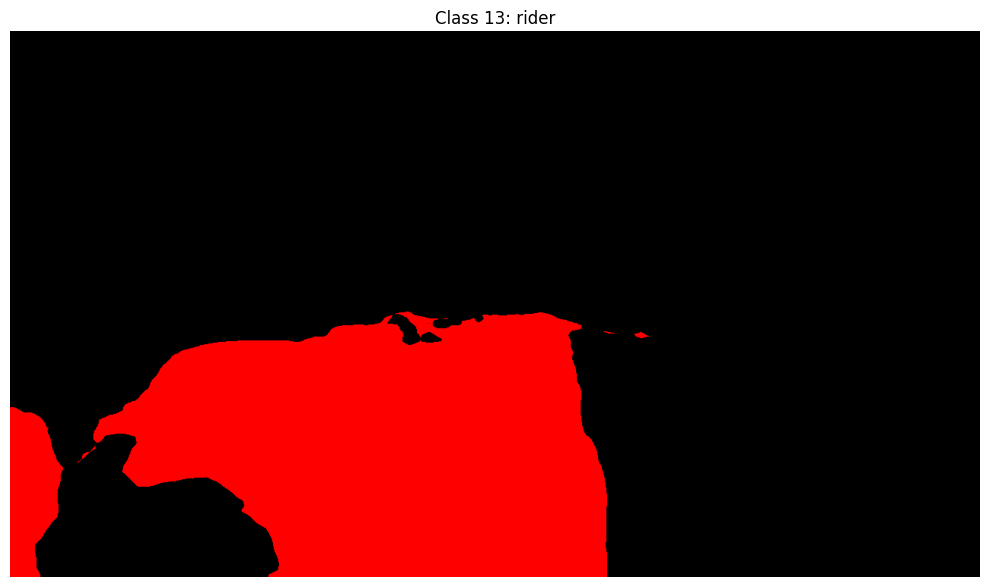

idx class:  14
nama class:  car


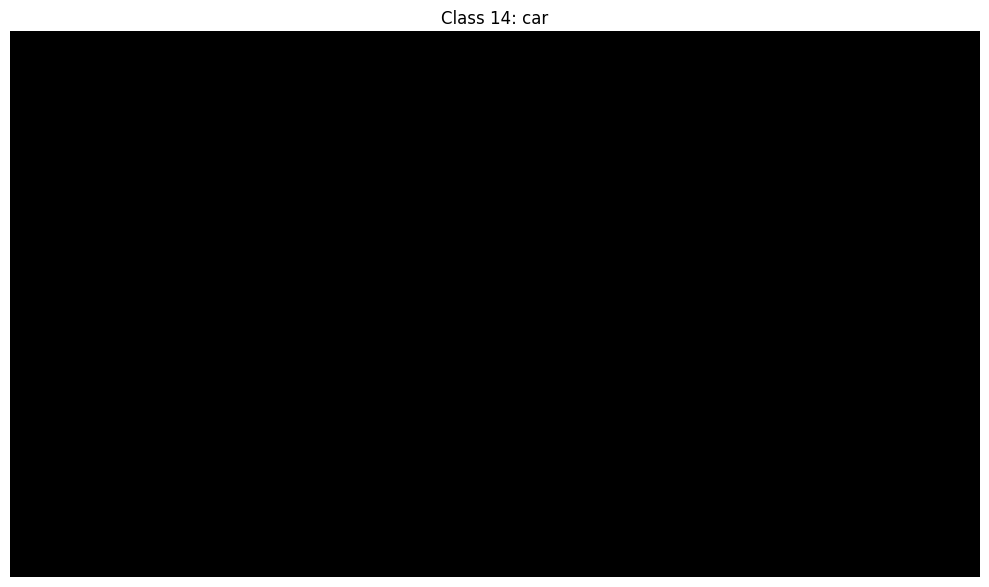

idx class:  15
nama class:  truck


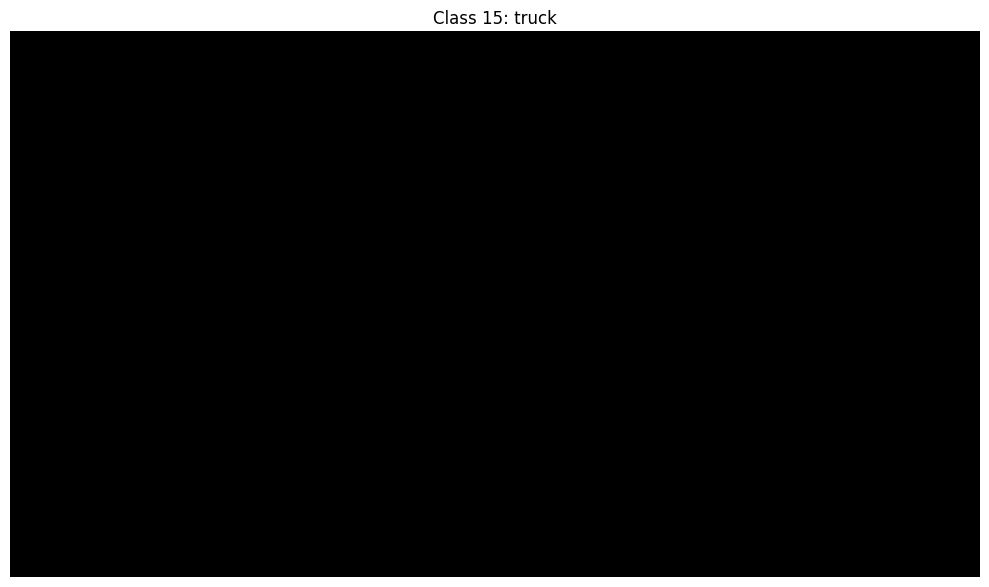

idx class:  16
nama class:  bus


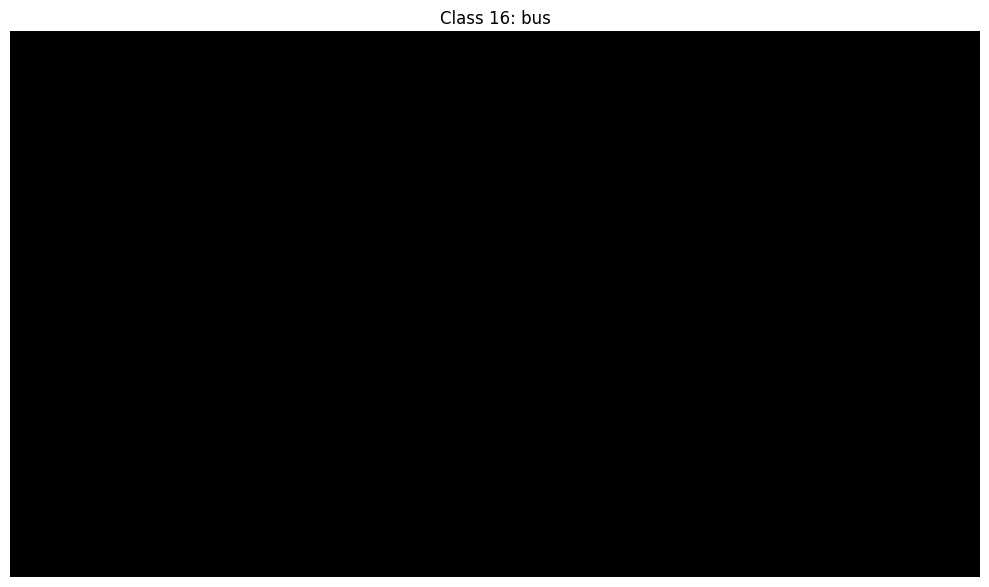

idx class:  17
nama class:  train


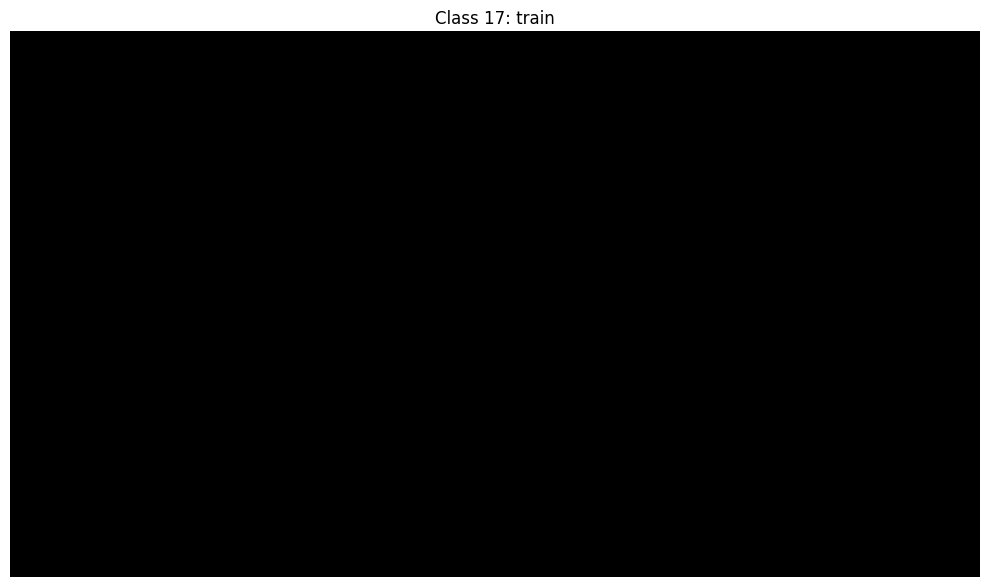

idx class:  18
nama class:  motorcycle


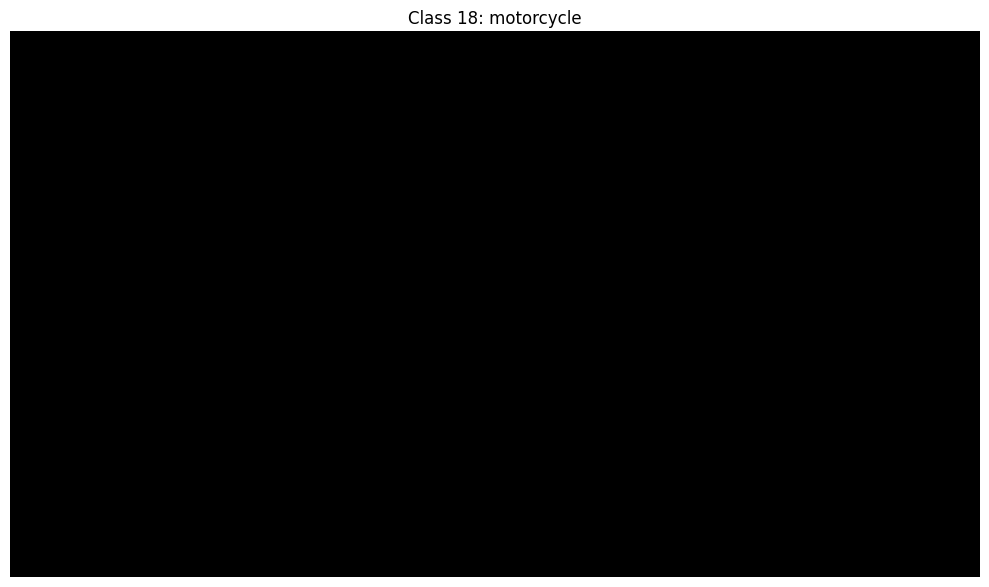

idx class:  19
nama class:  bicycle


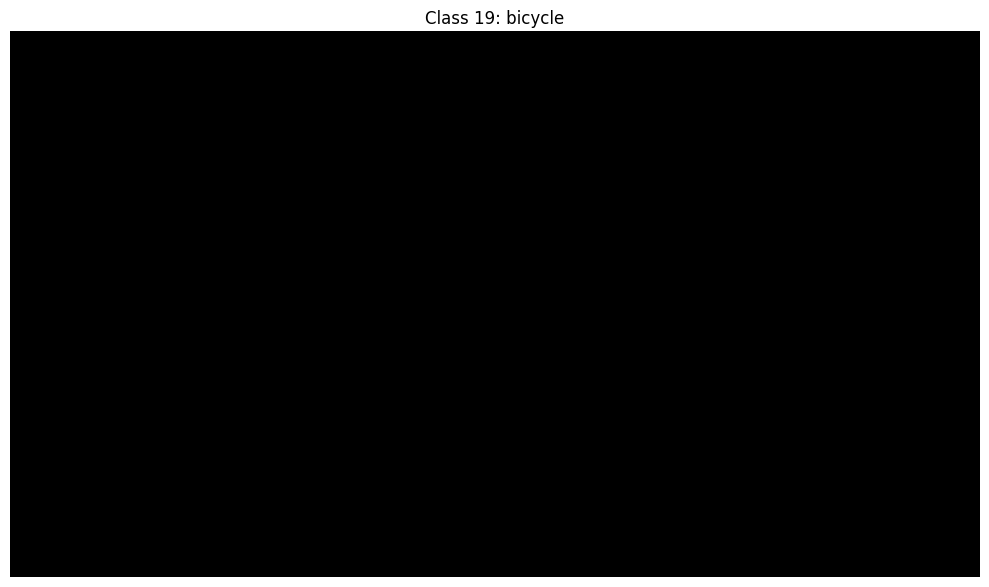

In [3]:
img = f'{dir_rgb_seg_map}/{files[5]}.png'
seg_img = cv2.imread(img)
print(seg_img.shape)

SEG_CLASSES = {
        'colors'        :[[0, 0, 0], [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156],  
                        [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0],
                        [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
                        [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100], 
                        [0, 80, 100], [0, 0, 230], [119, 11, 32]],  
        'classes'       : ['None', 'road', 'sidewalk', 'building', 'wall',
                            'fence', 'pole', 'traffic light', 'traffic sign', 
                            'vegetation', 'terrain', 'sky', 'person', 
                            'rider', 'car', 'truck', 'bus',
                            'train', 'motorcycle', 'bicycle']
    }

seg_one_hot = cls2one_hot(seg_img, n_class=len(SEG_CLASSES['classes']))
print(seg_one_hot.shape)

for i in range(20):
    print(f"Class {i}: {np.sum(seg_one_hot[i])} pixels")

for i in range(seg_one_hot.shape[0]):  # shape[0] = 20 channels
        print('idx class: ', i)
        print('nama class: ', SEG_CLASSES['classes'][i])
        img_class_r = seg_one_hot[i:i+1, :, :] * SEG_CLASSES['colors'][i][0]
        img_class_g = seg_one_hot[i:i+1, :, :] * SEG_CLASSES['colors'][i][1]
        img_class_b = seg_one_hot[i:i+1, :, :] * SEG_CLASSES['colors'][i][2]
        
        # Transpose to (H, W, C) for imshow
        img_class_rgb = np.concatenate([img_class_r, img_class_g, img_class_b], axis=0)
        img_class_rgb = np.transpose(img_class_rgb, (1, 2, 0))
        
        plt.figure(figsize=(10, 6))
        plt.imshow(img_class_rgb.astype(np.uint8))
        plt.title(f"Class {i}: {SEG_CLASSES['classes'][i]}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

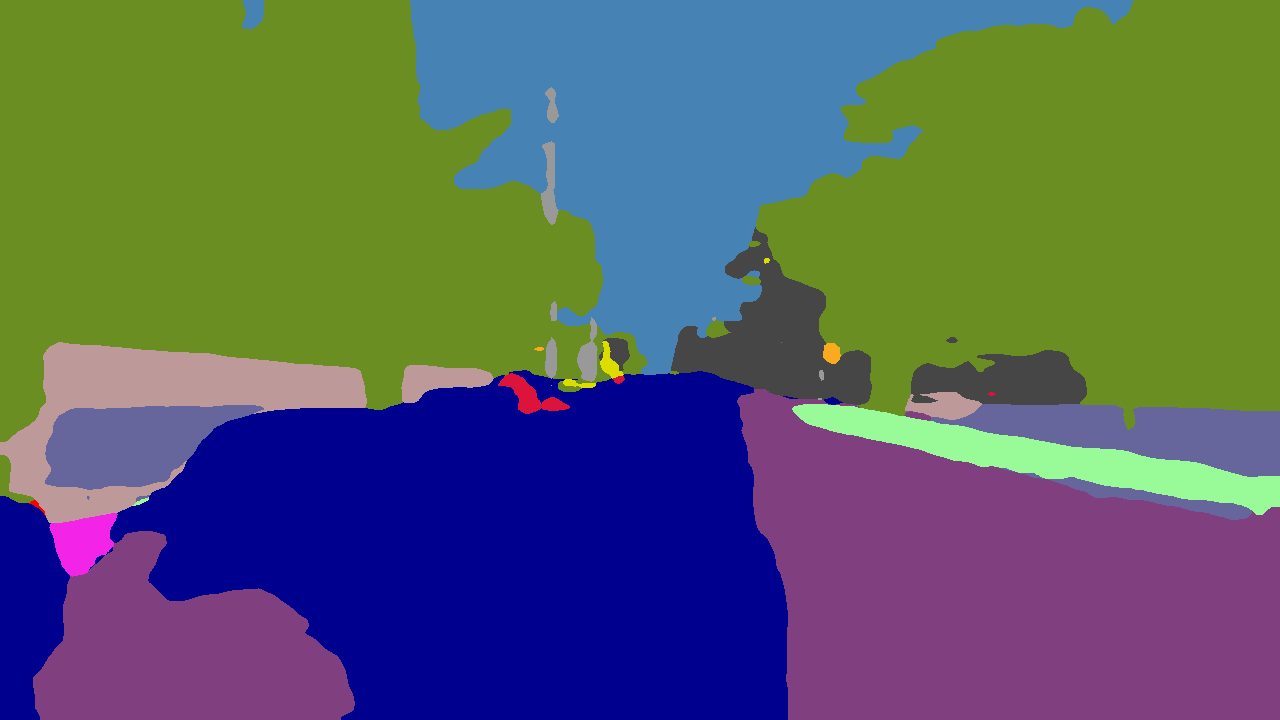

(720, 1280, 3)
class_map:  [[ 9  9  9 ...  9  9  9]
 [ 9  9  9 ...  9  9  9]
 [ 9  9  9 ...  9  9  9]
 ...
 [14 14 14 ...  1  1  1]
 [14 14 14 ...  1  1  1]
 [14 14 14 ...  1  1  1]]
shape GT segmentation one hot encoded:  (20, 720, 1280)
Class 0: 0 pixels
Class 1: 165981 pixels
Class 2: 2749 pixels
Class 3: 22962 pixels
Class 4: 28862 pixels
Class 5: 26510 pixels
Class 6: 2466 pixels
Class 7: 329 pixels
Class 8: 594 pixels
Class 9: 353520 pixels
Class 10: 15857 pixels
Class 11: 113486 pixels
Class 12: 1210 pixels
Class 13: 65 pixels
Class 14: 187009 pixels
Class 15: 0 pixels
Class 16: 0 pixels
Class 17: 0 pixels
Class 18: 0 pixels
Class 19: 0 pixels
idx class:  0
nama class:  None


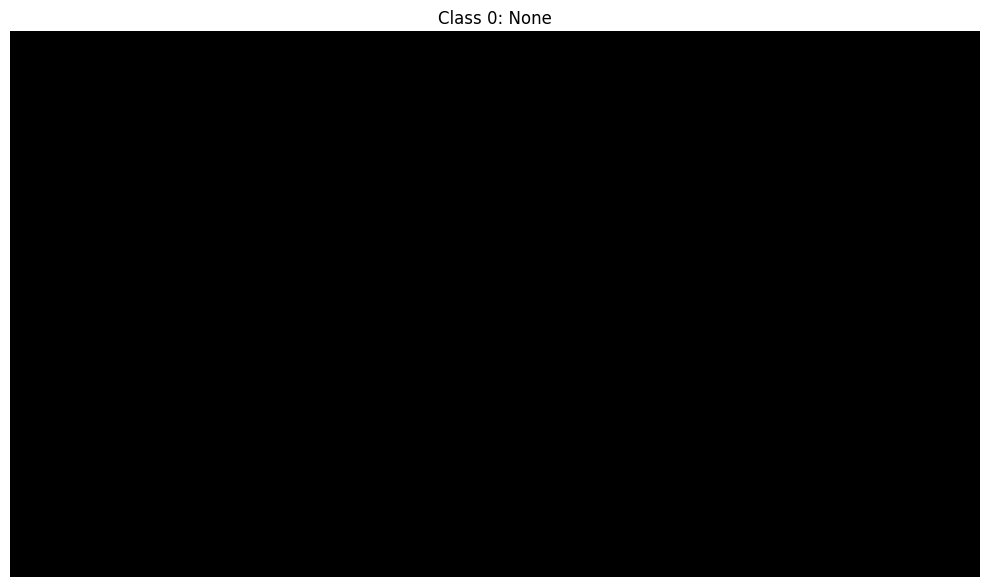

idx class:  1
nama class:  road


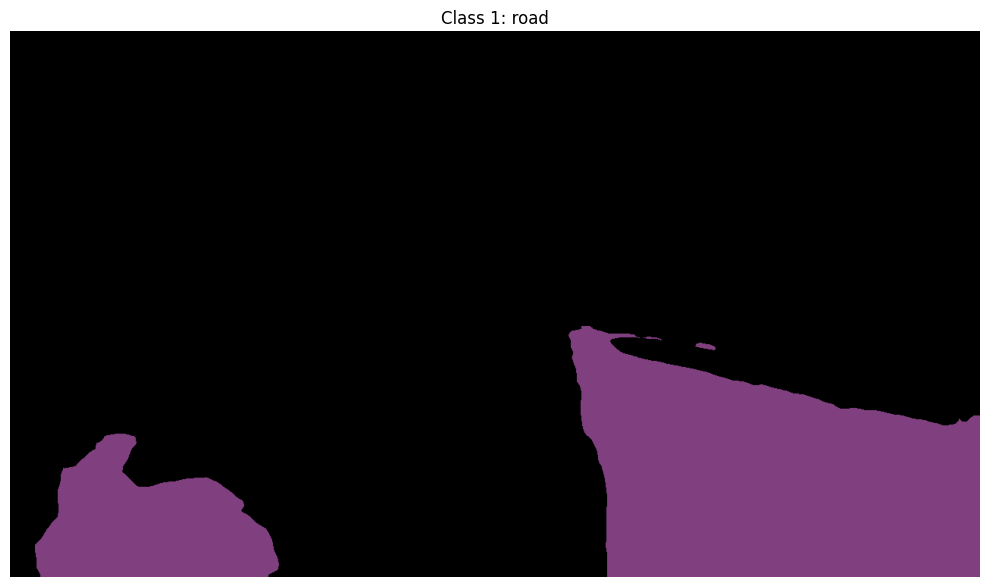

idx class:  2
nama class:  sidewalk


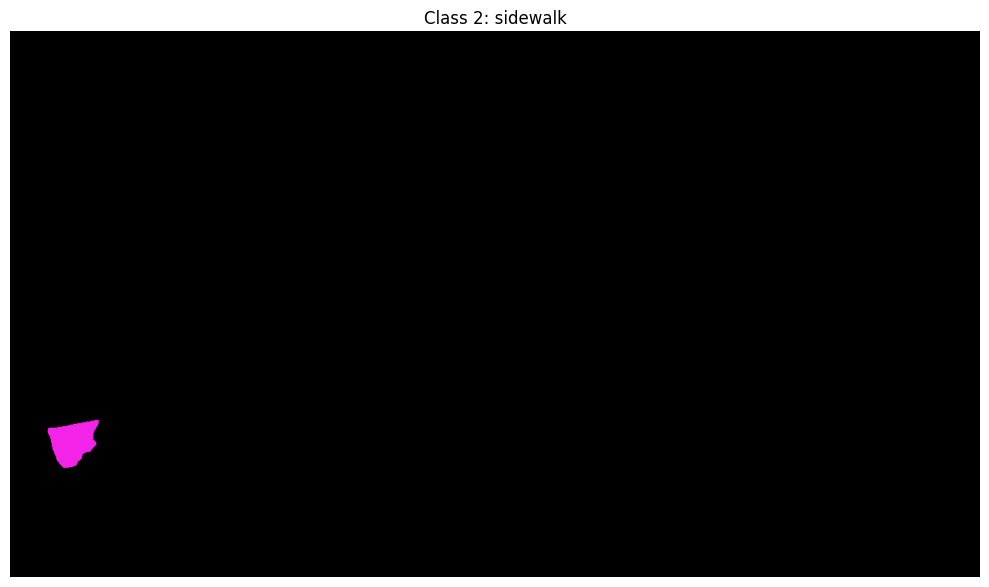

idx class:  3
nama class:  building


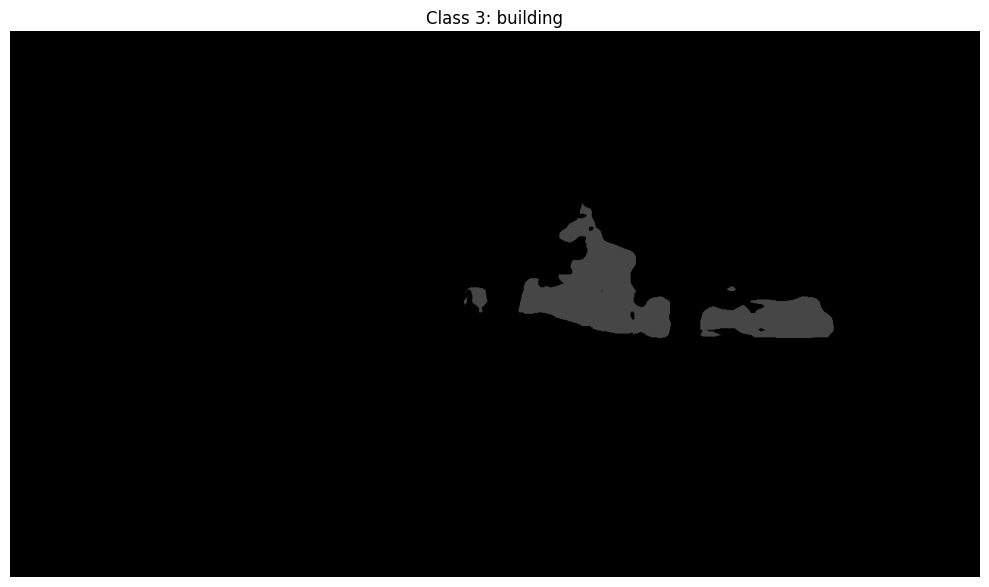

idx class:  4
nama class:  wall


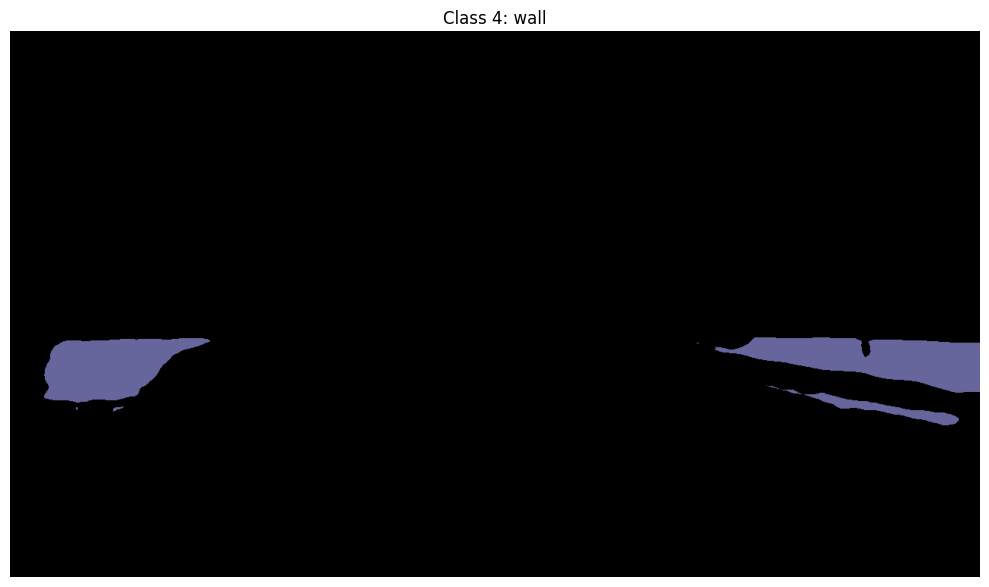

idx class:  5
nama class:  fence


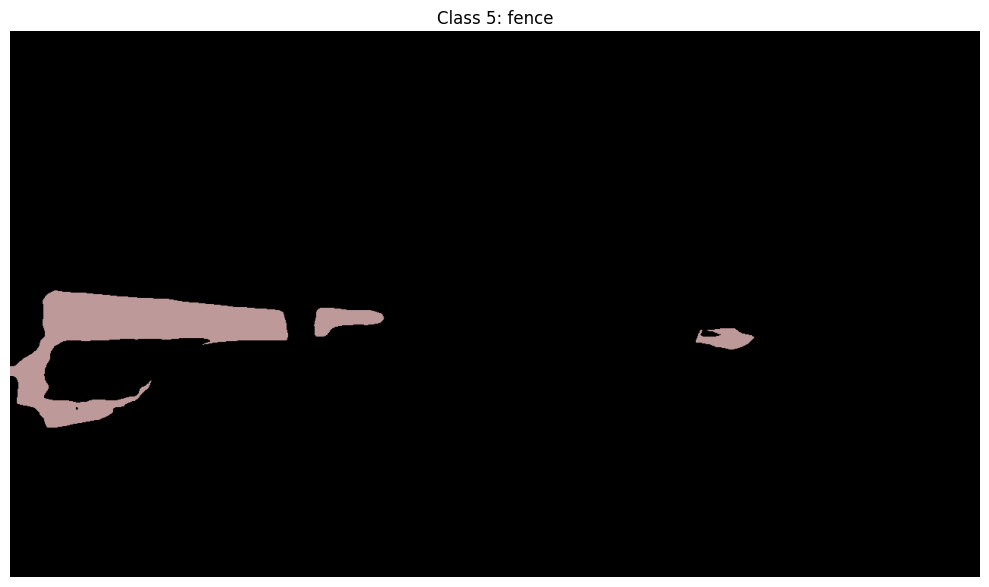

idx class:  6
nama class:  pole


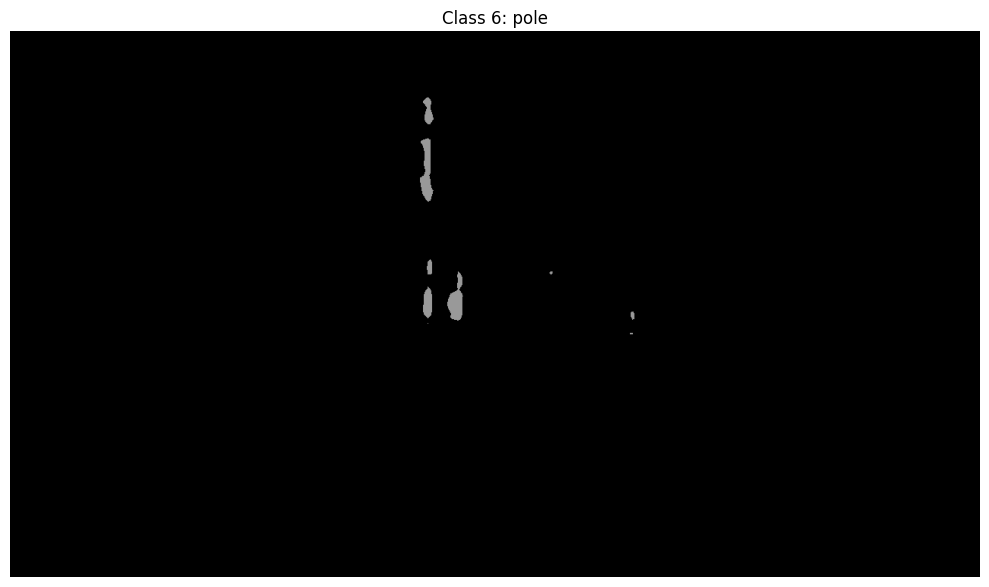

idx class:  7
nama class:  traffic light


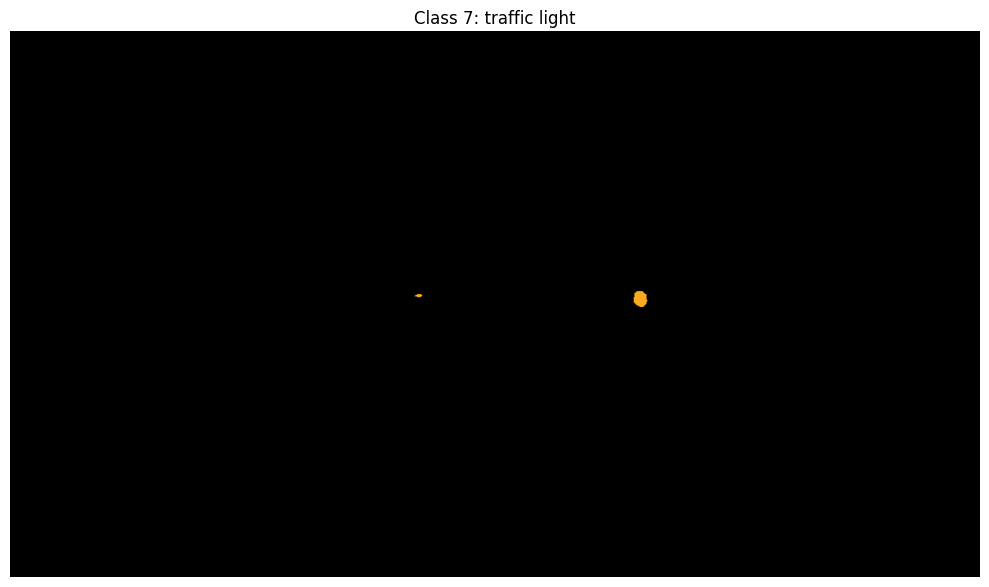

idx class:  8
nama class:  traffic sign


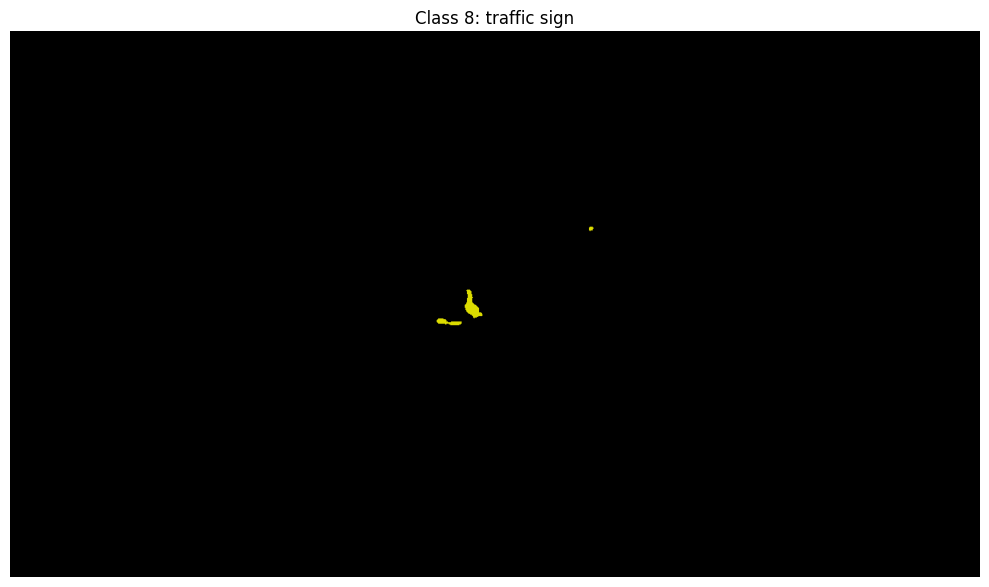

idx class:  9
nama class:  vegetation


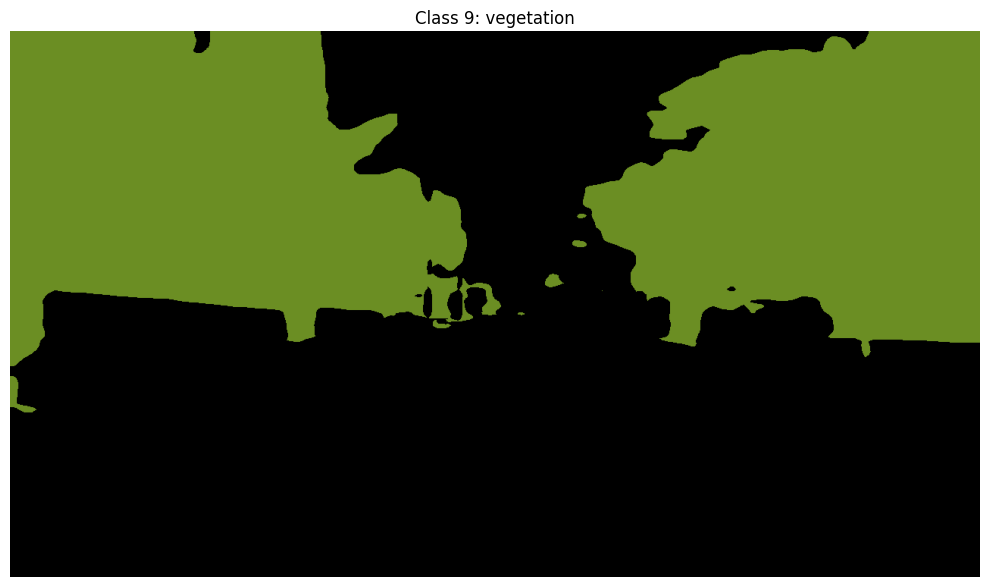

idx class:  10
nama class:  terrain


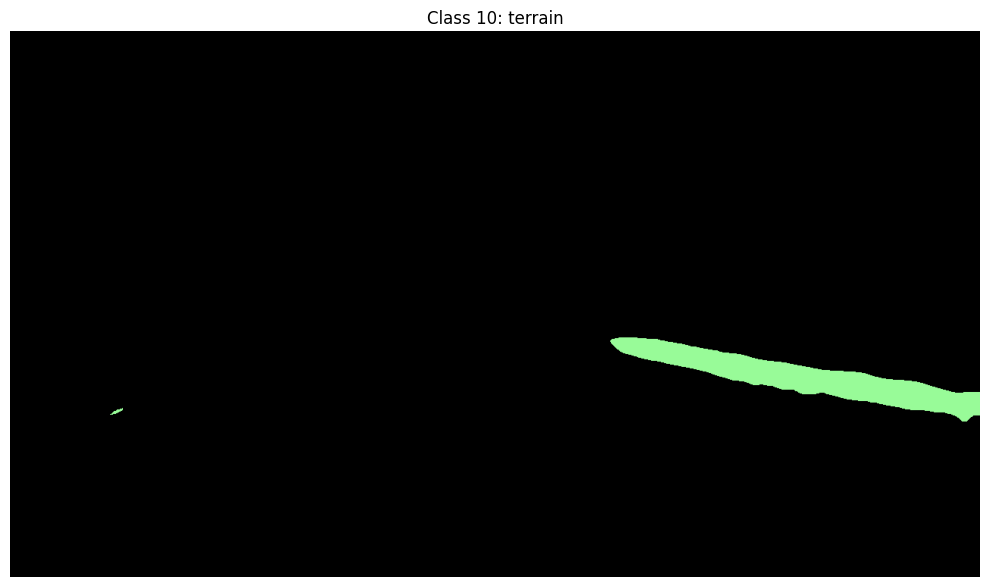

idx class:  11
nama class:  sky


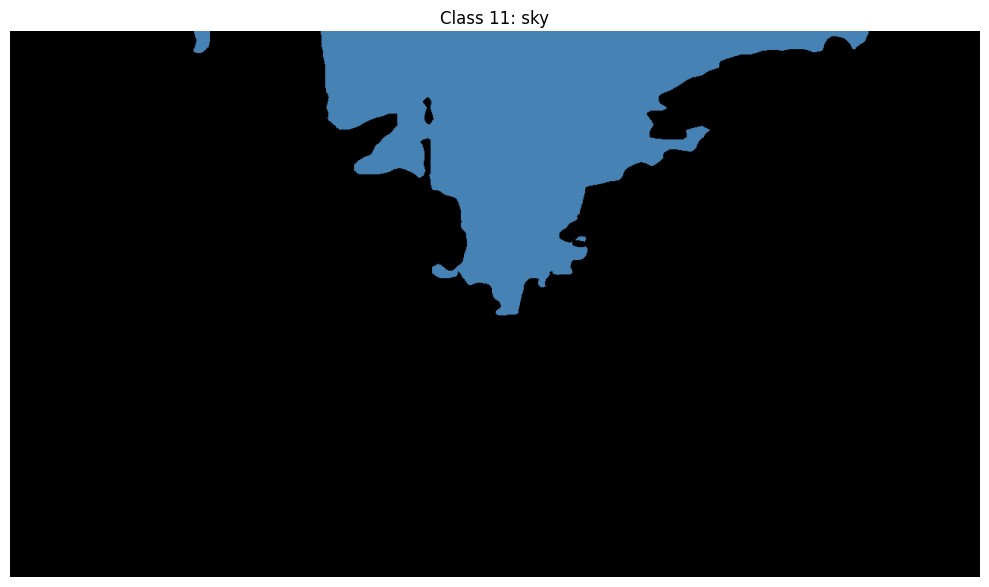

idx class:  12
nama class:  person


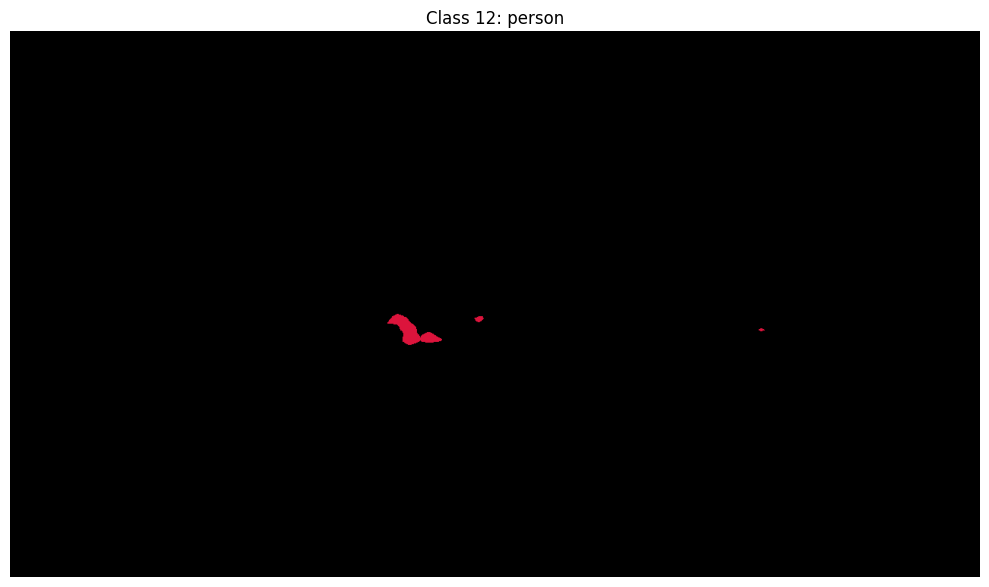

idx class:  13
nama class:  rider


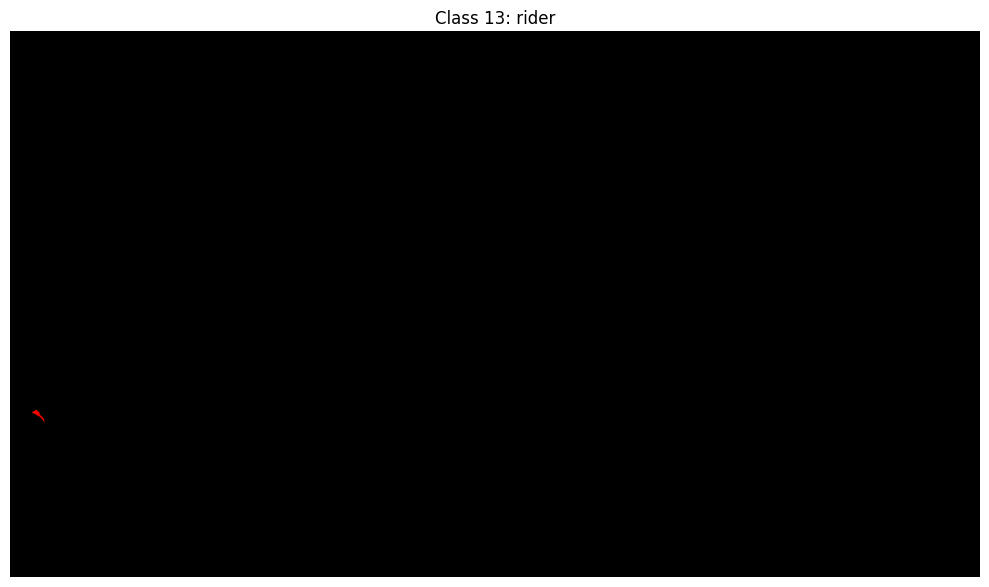

idx class:  14
nama class:  car


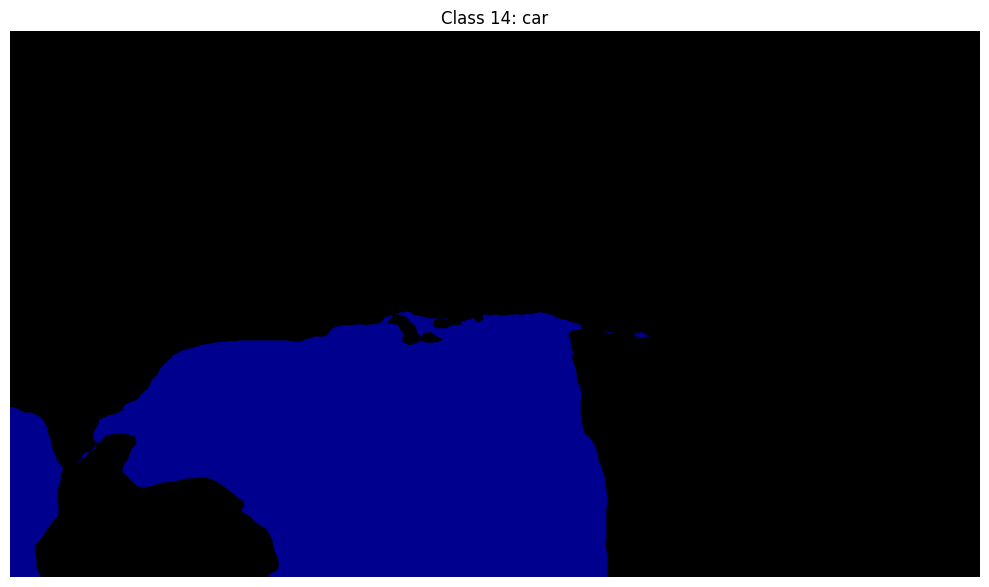

idx class:  15
nama class:  truck


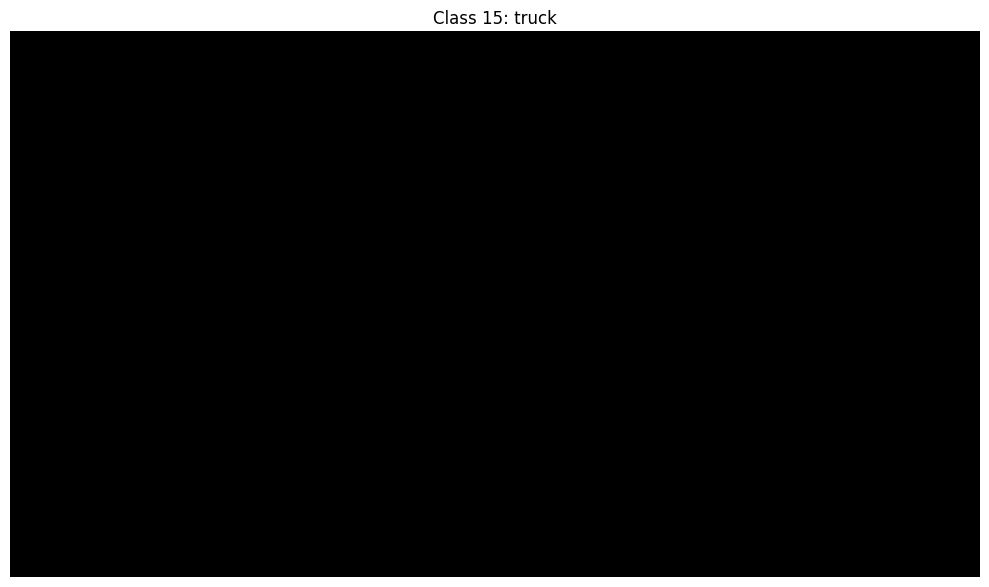

idx class:  16
nama class:  bus


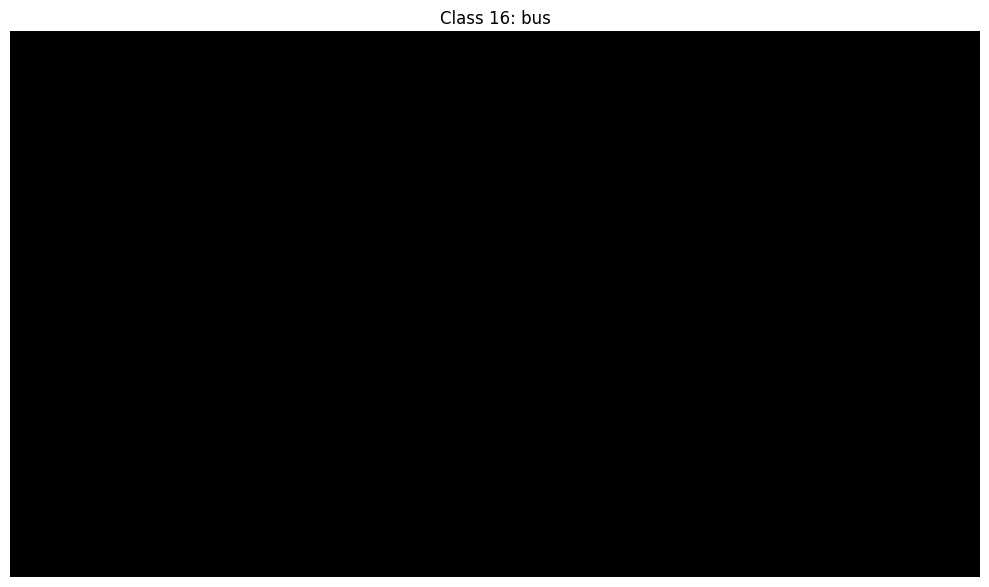

idx class:  17
nama class:  train


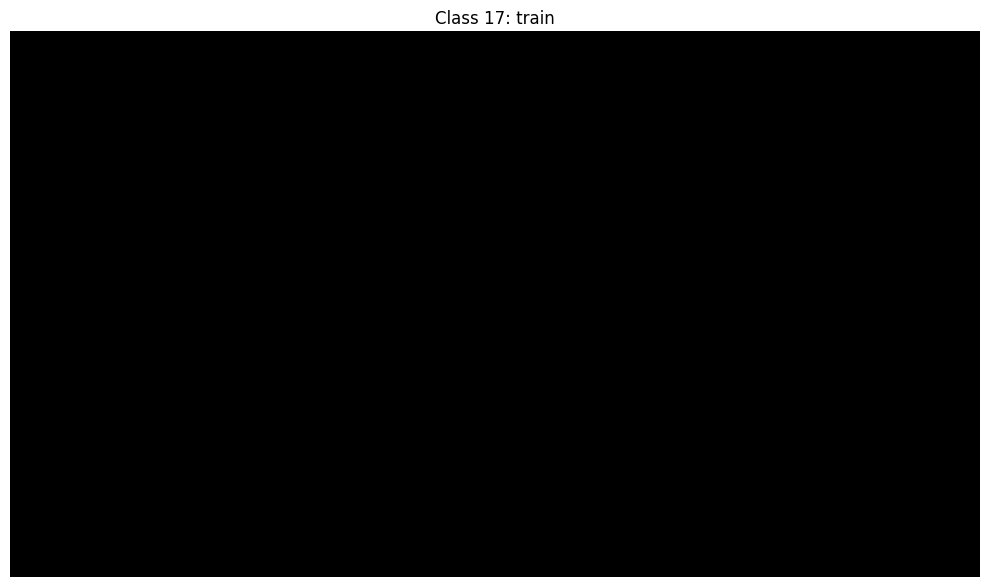

idx class:  18
nama class:  motorcycle


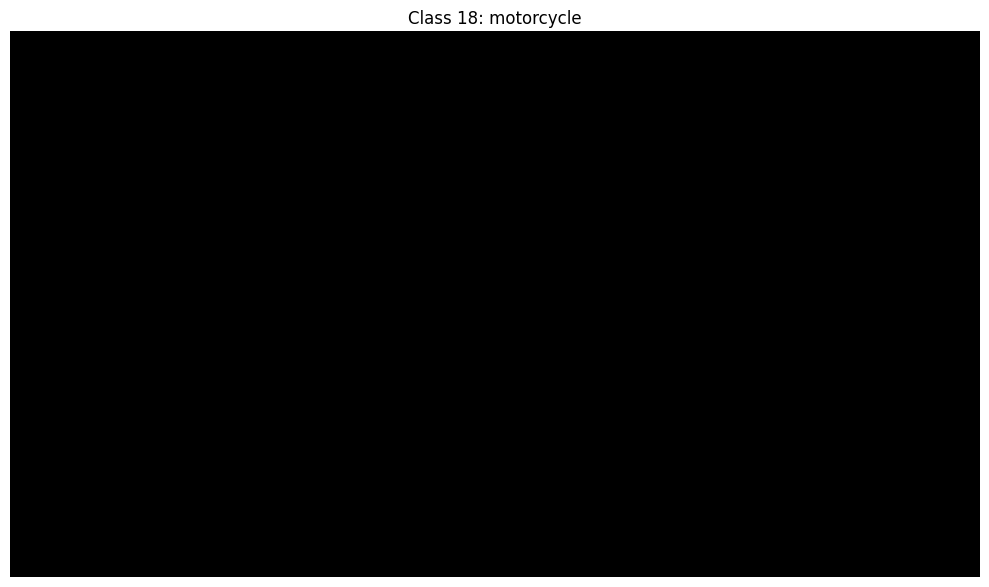

idx class:  19
nama class:  bicycle


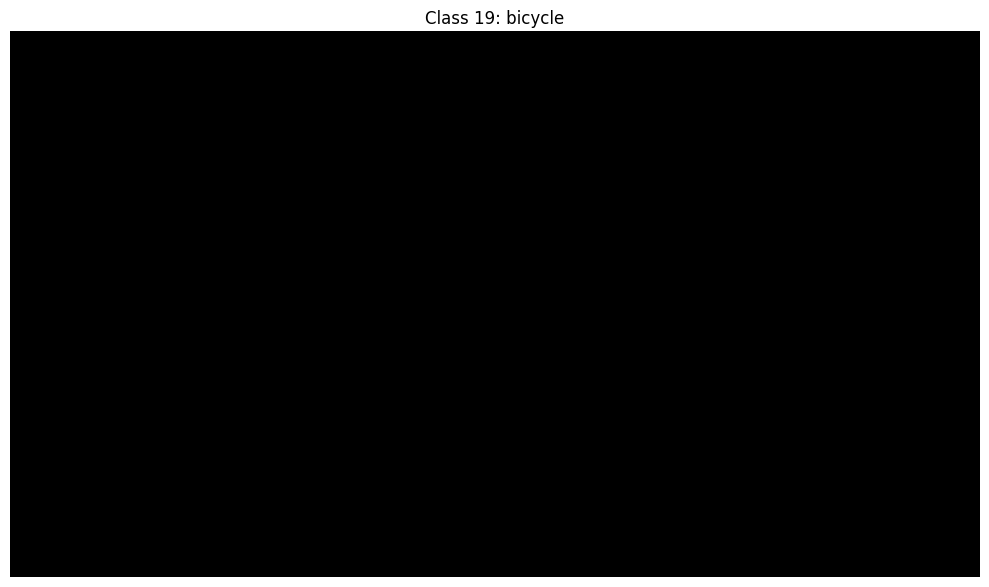

In [4]:
def rgb_to_class(rgb_image, color_palette):
    """Convert RGB segmentation image to class indices"""
    h, w, _ = rgb_image.shape
    class_map = np.zeros((h, w), dtype=np.uint8)
    
    # Match each pixel's RGB color to class index
    for i, color in enumerate(color_palette):
        # Create mask for this color (allow small tolerance for compression artifacts)
        mask = np.all(np.abs(rgb_image.astype(int) - color) < 10, axis=2)
        class_map[mask] = i
    
    return class_map

def cls_to_one_hot(ss_gt, n_class):
    if ss_gt.ndim == 3:
        ss_gt = ss_gt[:, :, 0] if ss_gt.shape[2] == 1 else ss_gt[:, :, 0]
    
    # Create one-hot: (H, W) → (H, W, C) → (C, H, W)
    result = (np.arange(n_class) == ss_gt[..., None]).astype(int)
    result = np.transpose(result, (2, 0, 1))
    return result

img = f'{dir_rgb_seg}/{files[5]}.png'
display(Image(filename=f'{dir_rgb_seg}/{files[5]}.png'))
seg_img = cv2.imread(img)
seg_img = cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB)
class_map = rgb_to_class(seg_img, config.SEG_CLASSES['colors'])
print(seg_img.shape)
print("class_map: ", class_map)

seg_one_hot = cls_to_one_hot(class_map, n_class=len(config.SEG_CLASSES['classes']))
print("shape GT segmentation one hot encoded: ",seg_one_hot.shape)

for i in range(20):
    print(f"Class {i}: {np.sum(seg_one_hot[i])} pixels")

for i in range(seg_one_hot.shape[0]):  # shape[0] = 20 channels
        print('idx class: ', i)
        print('nama class: ', config.SEG_CLASSES['classes'][i])
        
        # Note: seg_one_hot is (C, H, W), so we use [i:i+1] for channel
        img_class_r = seg_one_hot[i:i+1, :, :] * config.SEG_CLASSES['colors'][i][0]
        img_class_g = seg_one_hot[i:i+1, :, :] * config.SEG_CLASSES['colors'][i][1]
        img_class_b = seg_one_hot[i:i+1, :, :] * config.SEG_CLASSES['colors'][i][2]
        
        # Transpose to (H, W, C) for imshow
        img_class_rgb = np.concatenate([img_class_r, img_class_g, img_class_b], axis=0)
        img_class_rgb = np.transpose(img_class_rgb, (1, 2, 0))
        
        plt.figure(figsize=(10, 6))
        plt.imshow(img_class_rgb.astype(np.uint8))
        plt.title(f"Class {i}: {config.SEG_CLASSES['classes'][i]}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

## Visualize the depth map

Note: When the data used by tensor or deep learning network, the data format from HWC (height, width, channel) needs to be transposed to CHW (channel, height, width)

depth shape: (720, 1280)


[ WARN:0@7.216] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


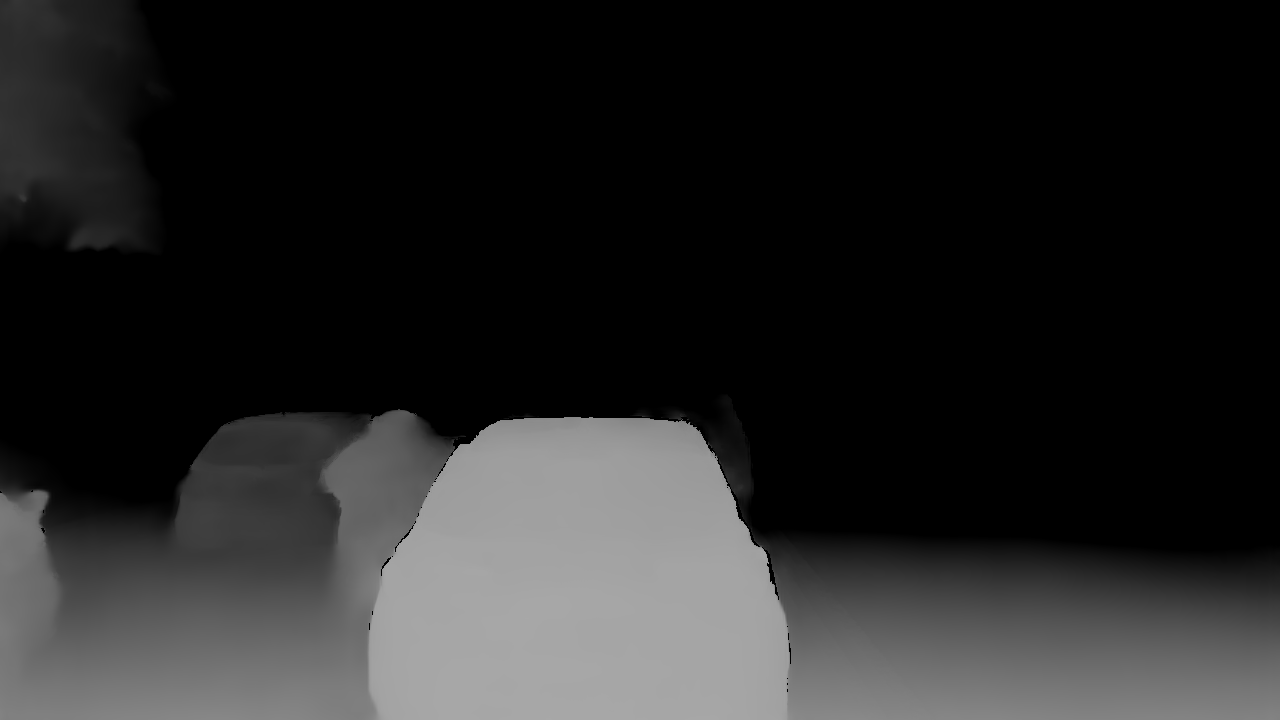

pcd ori shape: (720, 1280, 3)


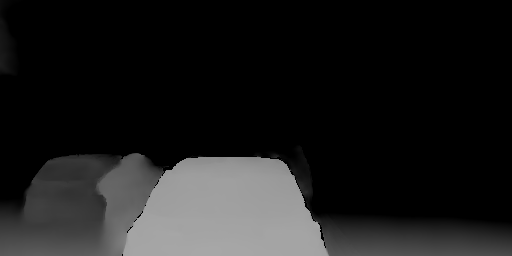

pcd crop-resized shape: (256, 512, 3)


In [5]:
# Implementasi load depth map dari npy
f = dir_depth_front / f'{files[5]}.npy'
depth_raw = np.load(f, allow_pickle=True)

print(f"depth shape: {depth_raw.shape}")

pcd_ori = np.nan_to_num(depth_raw, nan=40.0, posinf=40.0, neginf=0.3)
pcd_ori_msg = colorize_depth(pcd_ori)
cv2.imwrite("/media/mf/AUTODRIVING-4TB/ai23/temp/pcd_ori_msg.png", pcd_ori_msg)
display(Image(filename="/media/mf/AUTODRIVING-4TB/ai23/temp/pcd_ori_msg.png"))
print(f'pcd ori shape: {pcd_ori_msg.shape}')

pcd_crop_resized = np.nan_to_num(crop_matrix(depth_raw, resize=config.scale, D3=False, crop=[512, 1024]), nan=40.0, posinf=40.0, neginf=0.3)
pcd_crop_resized_img = colorize_depth(pcd_crop_resized)
cv2.imwrite("/media/mf/AUTODRIVING-4TB/ai23/temp/pcd_crop_resized_img.png", pcd_crop_resized_img)
display(Image(filename="/media/mf/AUTODRIVING-4TB/ai23/temp/pcd_crop_resized_img.png"))
print(f'pcd crop-resized shape: {pcd_crop_resized_img.shape}')

In [6]:
# Visualize pointcloud
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

# points = np.load(f'{dir_depth_front_pcd}/{files[5]}.npy')
# print(points.shape)
# points = np.column_stack([points['x'], points['y'], points['z']])
# print(points.shape)

pcd = pcd_crop_resized_img
pcd_xs = pcd[0:1,:,:]
print(pcd_xs[0,0,0])

fig = go.Figure(data=[go.Scatter3d(
    x=pcd_xs[:, 0],
    y=pcd_xs[:, 1],
    z=pcd_xs[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=pcd_xs[:, 2],  # Color by Z-height
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(
    title='Point Cloud Visualization',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    width=800,
    height=600
)

fig.show()

12.473819


## Project semantic segmentation to the depth map

## Visualize the global position from GNSS

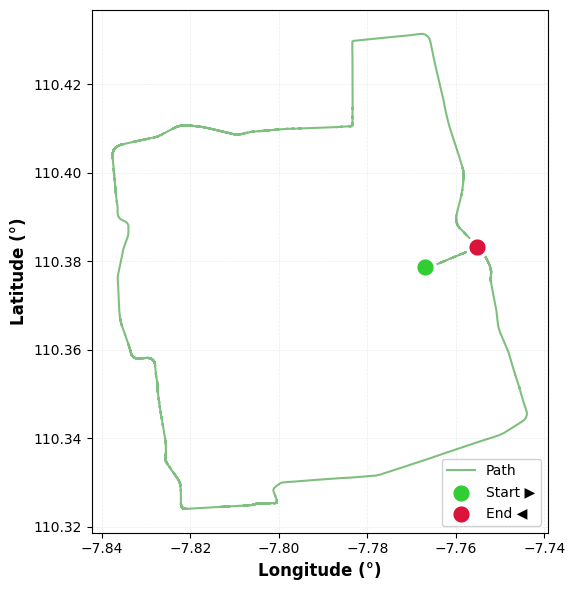

In [7]:
lats = []
lons = []

for file in files:
    with open(f'{dir_meta}/{file}.yml', 'r') as curr_metafile:
        current_meta = yaml.safe_load(curr_metafile)
        lat = current_meta["global_position_latlon"][0]
        lon = current_meta["global_position_latlon"][1]
        lats.append(lat)
        lons.append(lon)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lats, lons, 'g-', linewidth=1.5, label='Path', alpha=0.5)
ax.scatter(lats[0], lons[0], c='limegreen', s=200, label='Start ▶', zorder=6, edgecolors='white', linewidth=2.5)
ax.scatter(lats[-1], lons[-1], c='crimson', s=200, label='End ◀', zorder=6, edgecolors='white', linewidth=2.5)
ax.set_xlabel('Longitude (°)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

map_location = [-7.770255, 110.376824]
m = folium.Map(location=map_location, zoom_start=16, tiles="cartodb positron")

coordinates = list(zip(lats, lons))
folium.PolyLine(
    locations=coordinates,
    color='#3388FF',
    weight=4,
    opacity=0.7,
    tooltip=f'Total distance: {len(lats)} frames'
).add_to(m)
m

## Visualize bearing and bearing with MAF

example of metadata:

acceleration_xyz:

- 0.41194334626197815
- -9.8100004196167
- -0.3832031190395355

angular_speed_xyz:

- -0.001065264455974102
- -0.001065264455974102
- 0.007456851191818714

global_orientation_xyzw:

- -0.025195448742127476
- -0.021891778006499364
- 0.10988073192010497
- 0.9933841976652835

global_position_latlon:

- -7.768369
- 110.384111

local_orientation_xyzw:

- -0.002087681224096158
- -0.013272887367424801
- 0.4307845568275406
- 0.902354773715381

local_position_xyz:

- 9.747918158774555
- 3.167414469150018
- -3.5523661455913973

nanosec: 0199773043

sec: '1762315310'

velocity: 0.05

In [8]:
# TODO: 
# - check bearing antara gnss dan imu, mungkin cari offset nya juga untuk imu biar selaras dengan gnss
# - check routepoint dan convert routepoint latlon ke local position
# - check waypoint dari imu maupun gnss

meta = [yaml.safe_load(open(f"{dir_meta}/{meta_file}.yml", "r")) for meta_file in files]
jarak_frame = 100
lat = [m['global_position_latlon'][0] for m in meta][::jarak_frame]
lon = [m['global_position_latlon'][1] for m in meta][::jarak_frame]

In [9]:
gnss_yaw = latlon_to_yaw(lat[1:], lon[1:], lat[:-1], lon[:-1], offset=np.pi / 2.0)
gnss_yaw = np.append(gnss_yaw, gnss_yaw[-1])

quaternion_witmotion = [m['global_orientation_xyzw'] for m in meta][::jarak_frame]
imu_yaw_witmotion = quaternion_to_yaw(quaternion_witmotion)

quaternion_zed = [m['local_orientation_xyzw'] for m in meta][::jarak_frame]
imu_yaw_zed = quaternion_to_yaw(quaternion_zed, offset=0.0)

plt.figure(figsize=(10, 10))
scale = 0.3
plt.quiver(lon, lat, np.cos(gnss_yaw)*scale, np.sin(gnss_yaw)*scale, angles='xy', scale_units='xy', scale=100, color='orange', label='GNSS-based Bearing')
plt.quiver(lon, lat, np.cos(imu_yaw_witmotion)*scale, np.sin(imu_yaw_witmotion)*scale, angles='xy', scale_units='xy', scale=100, color='purple', label='IMU Witmotion-based Bearing')
# plt.quiver(lon, lat, np.cos(imu_yaw_zed)*scale, np.sin(imu_yaw_zed)*scale, angles='xy', scale_units='xy', scale=100, color='blue', label='IMU ZED 2i-based Bearing')
plt.title("GNSS vs IMU Bearing")
plt.axis("equal")
plt.xlabel('Longitude (deg)')
plt.ylabel('Latitude (deg)')
plt.grid()
plt.legend()
plt.savefig("/media/mf/AUTODRIVING-4TB/ai23/temp/bearing_viz.png", bbox_inches='tight', dpi=300)
plt.close()


In [10]:
import pandas as pd
import numpy as np
from collections import deque, OrderedDict

lat_list, lon_list = [], []
maf_bearing_list = []
n_buffer = 5
sin_angle_buff = deque(maxlen=n_buffer * config.data_rate if n_buffer != 0 else 1)

# Pre-fill buffer with first valid yaw angle (warm-up)
if n_buffer != 0 and len_files > 0:
    with open(f"{dir_meta}/{files[0]}.yml", 'r') as first_file:
        first_meta = yaml.safe_load(first_file)
    _, _, init_yaw = euler_from_quaternion(
        w=first_meta['global_orientation_xyzw'][3],
        x=first_meta['global_orientation_xyzw'][0],
        y=first_meta['global_orientation_xyzw'][1],
        z=first_meta['global_orientation_xyzw'][2],
        rad=False
    )
    # Pre-fill buffer with initial sine value
    for _ in range(len(sin_angle_buff)):
        sin_angle_buff.append(np.sin(np.radians(init_yaw)))

for filename in files:
    with open(f"{dir_meta}/{filename}.yml", 'r') as curr_metafile:
        curr_meta = yaml.safe_load(curr_metafile)
    
    lat, lon = curr_meta['global_position_latlon']
    lat_list.append(lat)
    lon_list.append(lon)
    
    _, _, global_yaw = euler_from_quaternion(
        w=curr_meta['global_orientation_xyzw'][3],
        x=curr_meta['global_orientation_xyzw'][0],
        y=curr_meta['global_orientation_xyzw'][1],
        z=curr_meta['global_orientation_xyzw'][2],
        rad=False
    )
    
    if n_buffer != 0:
        sin_angle_buff.append(np.sin(np.radians(global_yaw)))
        
        sin_mean = np.mean(sin_angle_buff)
        if 0 < global_yaw <= 90:  # Q1
            maf_yaw = np.degrees(np.arcsin(sin_mean))
        elif 90 < global_yaw <= 180:  # Q2
            maf_yaw = 180 - np.degrees(np.arcsin(sin_mean))
        elif -180 <= global_yaw < -90:  # Q3
            maf_yaw = -180 - np.degrees(np.arcsin(sin_mean))
        else:  # Q4: -90 <= global_yaw <= 0
            maf_yaw = np.degrees(np.arcsin(sin_mean))        
        maf_bearing_list.append(maf_yaw)
    else:
        maf_bearing_list.append(global_yaw)

plt.figure(figsize=(12, 10))
step = 100
lat_plot = lat_list[::step]
lon_plot = lon_list[::step]
maf_yaw_plot = maf_bearing_list[::step]

# Convert yaw to radians for quiver, apply offset if needed
# offset=np.pi/2 for North-aligned, np.pi*1.5 for East-aligned (check your coordinate system)
# yaw_rad = np.radians(maf_yaw_plot) + np.pi / 2.0  # adjust offset as needed
yaw_rad = np.radians(maf_yaw_plot)

scale = 0.2
plt.quiver(lon_plot, lat_plot, 
           np.cos(yaw_rad) * scale, 
           np.sin(yaw_rad) * scale,
           angles='xy', scale_units='xy', scale=100,
           color='purple', width=0.003, label='MAF Bearing')

plt.plot(lon_list, lat_list, c='lightgray', linewidth=0.5, alpha=0.5, label='Route')
plt.title("MAF-Filtered Bearing", fontsize=14)
plt.xlabel('Longitude (deg)')
plt.ylabel('Latitude (deg)')
plt.axis('equal')
plt.grid(linestyle='--', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
# plt.show()
output_path = f"/media/mf/AUTODRIVING-4TB/ai23/temp/maf_bearing_{n_buffer}.png"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
plt.close()
print(f"✅ MAF bearing saved to: {output_path}")

✅ MAF bearing saved to: /media/mf/AUTODRIVING-4TB/ai23/temp/maf_bearing_5.png


Berdasarkan hasil plot antara bearing dari GNSS dan IMU Witmotion, ketika ego vehicle pelan/ diam, 

bearing dari GNSS akan kabur dan dari IMU Witmotion akan converge menjadi akurat, 

tetapi ketika ego vehicle bergerak, bearing dari GNSS akan akurat sedangkan IMU Witmotion akan kabur.

Hasil terbaik memakai MAF dengan buffer 5 cukup.

## Visualize waypoint